<a href="https://colab.research.google.com/github/muriukimuchira/Agape-Chatbot/blob/main/Agape_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
pip install nltk

Intents.json

In [15]:
{
  "intents": [
    {
      "tag": "greeting",
      "patterns": ["hello", "hi", "good morning", "hey"],
      "responses": ["Welcome to Agape Enterprise. How may I assist you today?"]
    },
    {
      "tag": "mombasa_price",
      "patterns": [
        "price to mombasa",
        "ticket cost to mombasa",
        "how much is mombasa",
        "fare to mombasa"
      ],
      "responses": [
        "Nairobi to Mombasa: Standard Class KES 1,500, Luxury VIP KES 2,500."
      ]
    },
    {
      "tag": "kisumu_price",
      "patterns": [
        "price to kisumu",
        "ticket cost to kisumu",
        "fare to kisumu"
      ],
      "responses": [
        "Nairobi to Kisumu: Standard Class KES 1,800, Luxury VIP KES 2,800."
      ]
    },
    {
      "tag": "eldoret_price",
      "patterns": [
        "price to eldoret",
        "fare to eldoret",
        "ticket to eldoret"
      ],
      "responses": [
        "Nairobi to Eldoret: Standard Class KES 1,600."
      ]
    },
    {
      "tag": "departure_times",
      "patterns": [
        "departure times",
        "what time does the bus leave",
        "bus schedule"
      ],
      "responses": [
        "Please specify your destination: Mombasa, Kisumu, or Eldoret."
      ]
    },
    {
      "tag": "booking",
      "patterns": [
        "book a ticket",
        "i want to travel",
        "make a booking",
        "reserve a seat"
      ],
      "responses": [
        "Please provide your route, travel date, travel class, and number of passengers."
      ]
    },
    {
      "tag": "goodbye",
      "patterns": [
        "bye",
        "goodbye",
        "see you"
      ],
      "responses": [
        "Thank you for choosing Agape Enterprise. Have a safe journey."
      ]
    }
  ]
}

{'intents': [{'tag': 'greeting',
   'patterns': ['hello', 'hi', 'good morning', 'hey'],
   'responses': ['Welcome to Agape Enterprise. How may I assist you today?']},
  {'tag': 'mombasa_price',
   'patterns': ['price to mombasa',
    'ticket cost to mombasa',
    'how much is mombasa',
    'fare to mombasa'],
   'responses': ['Nairobi to Mombasa: Standard Class KES 1,500, Luxury VIP KES 2,500.']},
  {'tag': 'kisumu_price',
   'patterns': ['price to kisumu', 'ticket cost to kisumu', 'fare to kisumu'],
   'responses': ['Nairobi to Kisumu: Standard Class KES 1,800, Luxury VIP KES 2,800.']},
  {'tag': 'eldoret_price',
   'patterns': ['price to eldoret', 'fare to eldoret', 'ticket to eldoret'],
   'responses': ['Nairobi to Eldoret: Standard Class KES 1,600.']},
  {'tag': 'departure_times',
   'patterns': ['departure times',
    'what time does the bus leave',
    'bus schedule'],
   'responses': ['Please specify your destination: Mombasa, Kisumu, or Eldoret.']},
  {'tag': 'booking',
   'pat

agape_pricing_bot.py

In [16]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.classify import NaiveBayesClassifier
import pandas as pd # Added for CSV saving
from datetime import datetime # Added for dynamic CSV filename

# Download necessary text parsing resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 1. Official Agape Enterprise Core Operational Data - Updated to support routes
AGAPE_DATABASE = {
    "nairobi": {
        "mombasa": {"standard": 1500, "vip": 3000, "times": ["08:00 AM", "10:00 PM"]},
        "kisumu":  {"standard": 1200, "vip": 2500, "times": ["07:00 AM", "09:00 PM"]},
        "nakuru":  {"standard": 600,   "vip": 1200, "times": ["06:00 AM", "02:00 PM"]}
    },
    "mombasa": {
        "nairobi": {"standard": 1500, "vip": 3000, "times": ["09:00 AM", "11:00 PM"]},
        "kisumu":  {"standard": 2000, "vip": 4000, "times": ["07:00 AM", "01:00 PM"]}
    },
    "kisumu": {
        "nairobi": {"standard": 1200, "vip": 2500, "times": ["08:00 AM", "10:00 PM"]},
        "mombasa": {"standard": 2000, "vip": 4000, "times": ["07:00 AM", "01:00 PM"]}
    },
    "nakuru": {
        "nairobi": {"standard": 600,   "vip": 1200, "times": ["06:00 AM", "02:00 PM"]}
    }
}

# Dynamically extract all unique cities involved in the routes
ALL_CITIES = sorted(list(set(AGAPE_DATABASE.keys()).union(*[AGAPE_DATABASE[origin].keys() for origin in AGAPE_DATABASE])))

# 2. Train an NLTK Classifier to identify "pricing_inquiry" intents
training_corpus = [
    ("how much is a ticket to mombasa", "pricing_inquiry"),
    ("what are the bus prices for nakuru", "pricing_inquiry"),
    ("i want to check ticket rates to kisumu", "pricing_inquiry"),
    ("fare breakdown for luxury vip class", "pricing_inquiry"),
    ("how much will it cost for 3 passengers", "pricing_inquiry"),
    ("hello, good morning", "greeting"),
    ("hi there, anyone available?", "greeting"),
    ("from mombasa to kisumu price", "pricing_inquiry"),
    ("kisumu to nairobi tickets", "pricing_inquiry"),
    ("price", "pricing_inquiry"),
    ("fare", "pricing_inquiry"),
    ("cost", "pricing_inquiry"),
    ("how much", "pricing_inquiry"),
    ("no", "end_conversation"), # Added for ending conversation
    ("nothing else", "end_conversation"), # Added for ending conversation
    ("that's all", "end_conversation"), # Added for ending conversation
    ("thank you", "end_conversation"), # Added for ending conversation
    ("bye", "end_conversation"), # Added for ending conversation
    ("goodbye", "end_conversation") # Added for ending conversation
]

STOP_WORDS = set(stopwords.words('english'))

def extract_features(text):
    """Tokenizes and cleans text to extract key informational tokens."""
    tokens = word_tokenize(text.lower())
    cleaned = [w for w in tokens if w.isalnum() and w not in STOP_WORDS]
    return {word: True for word in cleaned}

# Vectorize data and train the classifier engine
vectorized_corpus = [(extract_features(text), intent) for text, intent in training_corpus]
intent_classifier = NaiveBayesClassifier.train(vectorized_corpus)

# 3. Dynamic Extraction and Pricing Math Logic - MODIFIED for multi-turn interaction

def parse_passenger_count(text):
    """Improved regex parsing and word-to-number conversion for passenger count."""
    clean_text = text.lower()

    # Dictionary for number words
    number_words = {
        "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
        "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
        # Add more if necessary, but typically booking counts are small
    }

    # Try to find digits first
    numbers = re.findall(r'\b\d+\b', clean_text)
    if numbers:
        count = int(numbers[0])
        if count > 0:
            return count # Valid positive digit count
        else:
            return 0 # Invalid (zero or negative) digit count

    # If no digits, try to find number words
    for word, value in number_words.items():
        if word in clean_text:
            # Check if the found word is not part of a larger word (e.g., "someone")
            # This is a simple check, could be more sophisticated if needed
            if re.search(r'\b' + re.escape(word) + r'\b', clean_text):
                return value # Valid number word count

    return 0 # No valid number (digit or word) found or invalid count (0 or negative)

# Define conversation states
STATE_WAITING_FOR_ROUTE = "waiting_for_route"
STATE_WAITING_FOR_PASSENGERS = "waiting_for_passengers"
STATE_WAITING_FOR_CLASS = "waiting_for_class"
STATE_COLLECTING_PASSENGER_NAME = "collecting_passenger_name"
STATE_COLLECTING_PASSENGER_PHONE = "collecting_passenger_phone"
STATE_WAITING_FOR_TRAVEL_TIME = "waiting_for_travel_time" # Renamed for clarity, for overall booking time

# Global or persistent context for the conversation
conversation_context = {
    "state": STATE_WAITING_FOR_ROUTE,
    "origin": None,
    "destination": None,
    "passenger_count": None,
    "travel_class": None,
    "full_names": [],
    "phone_numbers": [],
    "travel_time": None,
    "total_fare": None,
    "schedules": None,
    "pricing_inquiry_active": False,
    "current_passenger_index": 0
}

def reset_conversation_context():
    global conversation_context
    conversation_context = {
        "state": STATE_WAITING_FOR_ROUTE,
        "origin": None,
        "destination": None,
        "passenger_count": None,
        "travel_class": None,
        "full_names": [],
        "phone_numbers": [],
        "travel_time": None,
        "total_fare": None,
        "schedules": None,
        "pricing_inquiry_active": False,
        "current_passenger_index": 0,
    }

def process_pricing_inquiry_turn(user_input):
    global conversation_context
    clean_input = user_input.lower()
    bot_response = ""
    inquiry_completed_flag = False # Flag to indicate if a full inquiry was completed

    current_state = conversation_context["state"]
    passenger_count = conversation_context["passenger_count"]
    current_passenger_index = conversation_context["current_passenger_index"]

    if current_state == STATE_WAITING_FOR_ROUTE:
        origin_city = None
        destination_city = None

        city_pattern = r'\b(' + '|'.join(re.escape(city) for city in ALL_CITIES) + r')\b'
        found_cities_in_order = []
        for match in re.finditer(city_pattern, clean_input):
            found_cities_in_order.append(match.group(1))

        seen = set()
        unique_found_cities_in_order = []
        for city in found_cities_in_order:
            if city not in seen:
                unique_found_cities_in_order.append(city)
                seen.add(city)

        from_to_match = re.search(r"from\s+" + city_pattern + r"\s+to\s+" + city_pattern, clean_input)
        to_from_match = re.search(r"to\s+" + city_pattern + r"\s+from\s+" + city_pattern, clean_input)

        if from_to_match:
            origin_city = from_to_match.group(1)
            destination_city = from_to_match.group(2)
        elif to_from_match:
            destination_city = to_from_match.group(1)
            origin_city = to_from_match.group(2)
        elif len(unique_found_cities_in_order) >= 2:
            origin_city = unique_found_cities_in_order[0]
            destination_city = unique_found_cities_in_order[1]
        elif len(unique_found_cities_in_order) == 1:
            origin_city = "nairobi"
            destination_city = unique_found_cities_in_order[0]

        if not origin_city or not destination_city:
            bot_response = ("I am sorry, I couldn't identify the origin and destination cities. "
                            f"Our active routes are between {', '.join([c.title() for c in ALL_CITIES])}. Please specify your route clearly.")
            conversation_context["pricing_inquiry_active"] = False
        elif origin_city not in AGAPE_DATABASE or destination_city not in AGAPE_DATABASE[origin_city]:
            bot_response = (f"I am sorry, the route from {origin_city.title()} to {destination_city.title()} does not exist in our system at the moment. "
                            f"Our active routes are between {', '.join([c.title() for c in ALL_CITIES])}.")
            conversation_context["pricing_inquiry_active"] = False
        else:
            conversation_context["origin"] = origin_city
            conversation_context["destination"] = destination_city
            conversation_context["state"] = STATE_WAITING_FOR_PASSENGERS
            conversation_context["pricing_inquiry_active"] = True
            bot_response = "Great! How many passengers are traveling?"

    elif current_state == STATE_WAITING_FOR_PASSENGERS:
        passenger_count_input = parse_passenger_count(clean_input)
        if passenger_count_input > 0:
            conversation_context["passenger_count"] = passenger_count_input
            conversation_context["state"] = STATE_WAITING_FOR_CLASS
            bot_response = "And what class would you prefer? Please respond with 'Standard' or 'VIP'."
        else:
            bot_response = "Please enter a valid number of passengers (e.g., '2 passengers' or 'two passengers')."
            conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_WAITING_FOR_CLASS:
        travel_class = "standard" # Default
        if "vip" in clean_input or "luxury" in clean_input:
            travel_class = "vip"
        conversation_context["travel_class"] = travel_class

        # All info gathered for pricing, now collect booking details
        origin_city = conversation_context["origin"]
        destination_city = conversation_context["destination"]
        passenger_count = conversation_context["passenger_count"]

        route_info = AGAPE_DATABASE[origin_city][destination_city]
        base_fare = route_info[travel_class]
        total_fare = base_fare * passenger_count
        schedules = route_info["times"]

        class_label = "Luxury VIP Class" if travel_class == "vip" else "Standard Class"
        conversation_context["total_fare"] = total_fare # Store total fare for final summary
        conversation_context["schedules"] = schedules # Store schedules for final summary

        bot_response = (
            f"Hello! Welcome to Agape Enterprise. Here is your requested fare breakdown:\n\n"
            f" * Route: {origin_city.title()} to {destination_city.title()}\n"
            f" * Selected Class: {class_label}\n"
            f" * Price per Passenger: KES {base_fare:,}\n"
            f" * Number of Passengers: {passenger_count}\n"
            f" -----------------------------------------------\n"
            f" **TOTAL AMOUNT PAYABLE: KES {total_fare:,}**\n\n"
            f"Our available daily departure times for this route are: {', '.join(schedules)}.\n\n"
        )

        conversation_context["state"] = STATE_COLLECTING_PASSENGER_NAME
        conversation_context["current_passenger_index"] = 0
        bot_response += f"To proceed with booking, please provide the full name for Passenger 1."
        conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_COLLECTING_PASSENGER_NAME:
        conversation_context["full_names"].append(user_input.strip().title())
        conversation_context["state"] = STATE_COLLECTING_PASSENGER_PHONE
        bot_response = f"Thank you, {conversation_context['full_names'][current_passenger_index]}. Please provide the phone number for Passenger {current_passenger_index + 1}."
        conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_COLLECTING_PASSENGER_PHONE:
        phone_number = re.sub(r'[^0-9]', '', user_input) # Keep only digits
        if len(phone_number) >= 8: # Basic validation for phone number length
            conversation_context["phone_numbers"].append(phone_number)
            conversation_context["current_passenger_index"] += 1

            if conversation_context["current_passenger_index"] < passenger_count:
                # Still more passengers to collect details for
                conversation_context["state"] = STATE_COLLECTING_PASSENGER_NAME
                bot_response = f"Got it. Now, please provide the full name for Passenger {conversation_context['current_passenger_index'] + 1}."
            else:
                # All passenger names and phones collected, ask for travel time
                conversation_context["state"] = STATE_WAITING_FOR_TRAVEL_TIME
                available_times = conversation_context["schedules"]
                bot_response = (f"Thank you for providing all passenger details. Finally, please specify your preferred travel time for the booking "
                                f"from the available times: {', '.join(available_times)}.")
            conversation_context["pricing_inquiry_active"] = True
        else:
            bot_response = "Please enter a valid phone number with at least 8 digits."
            conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_WAITING_FOR_TRAVEL_TIME:
        preferred_time = user_input.strip().upper()
        available_times = conversation_context["schedules"]

        # Basic validation for time format and availability
        if preferred_time in [t.upper() for t in available_times]:
            conversation_context["travel_time"] = preferred_time

            # All booking details gathered, provide summary and save to CSV
            origin_city = conversation_context["origin"]
            destination_city = conversation_context["destination"]
            passenger_count = conversation_context["passenger_count"]
            travel_class = conversation_context["travel_class"]
            full_names = conversation_context["full_names"]
            phone_numbers = conversation_context["phone_numbers"]
            total_fare = conversation_context["total_fare"]

            class_label = "Luxury VIP Class" if travel_class == "vip" else "Standard Class"

            summary_text = f"Thank you for providing all the details!\n\nHere is a summary of your booking for the route from {origin_city.title()} to {destination_city.title()}:\n\n"
            for i in range(passenger_count):
                summary_text += f" * Passenger {i+1} Name: {full_names[i]}\n"
                summary_text += f" * Passenger {i+1} Phone: {phone_numbers[i]}\n"

            summary_text += f" * Selected Class: {class_label}\n"
            summary_text += f" * Number of Passengers: {passenger_count}\n"
            summary_text += f" * Preferred Travel Time: {preferred_time}\n"
            summary_text += f" * Total Amount Payable: KES {total_fare:,}\n\n"

            bot_response = summary_text

            # Prepare data for CSV
            booking_records = []
            for i in range(passenger_count):
                record = {
                    "Route_Origin": origin_city.title(),
                    "Route_Destination": destination_city.title(),
                    "Selected_Class": class_label,
                    "Total_Passengers_in_Booking": passenger_count,
                    "Passenger_Index": i + 1,
                    "Passenger_Name": full_names[i],
                    "Passenger_Phone": phone_numbers[i],
                    "Preferred_Travel_Time": preferred_time,
                    "Total_Amount_Payable_for_Booking": total_fare,
                }
                booking_records.append(record)

            booking_df = pd.DataFrame(booking_records)
            csv_filename = "agape_booking_" + datetime.now().strftime("%Y%m%d_%H%M%S") + ".csv"
            booking_df.to_csv(csv_filename, index=False)
            bot_response += f"Your booking details have been saved to {csv_filename}.\n\n"
            bot_response += f"A Agape Enterprise agent will contact you shortly to confirm your booking. We appreciate your trust in Agape Enterprise and look forward to serving you.\n\nHave a safe and pleasant journey!"

            reset_conversation_context() # Reset for a new inquiry
            inquiry_completed_flag = True # Mark as completed
        else:
            available_times_str = ', '.join(available_times)
            bot_response = (f"I'm sorry, '{user_input}' is not a valid or available time for this route. "
                            f"Please choose from: {available_times_str}.")
            conversation_context["pricing_inquiry_active"] = True
    else:
        bot_response = "An unexpected error occurred. Let's start over. Please tell me your route."
        reset_conversation_context()

    return bot_response, inquiry_completed_flag


# 4. Interactive Chat Loop Console
print("="*65)
print(" Agape Enterprise Pricing Chatbot")
print("="*65)
new_greeting_cities = ', '.join([c.title() for c in ALL_CITIES])
print(f"Bot: Hello! Ask me about bus ticket prices between any of these cities: {new_greeting_cities}.")
print("Bot: To get started, please tell me your desired route (e.g., 'Nairobi to Mombasa').")

while True:
    user_msg = input("\nYou: ").strip()
    if user_msg.lower() in ['exit', 'quit']:
        print("Shutting down engine console. Goodbye!")
        break

    bot_reply = "" # Initialize bot_reply
    inquiry_completed = False # Initialize inquiry_completed flag

    if not conversation_context["pricing_inquiry_active"]:
        features = extract_features(user_msg)
        predicted_intent = intent_classifier.classify(features)

        if predicted_intent == "greeting":
            print("\nBot: Hello! Welcome to Agape Enterprise. Which route's pricing or schedule can I assist you with today?")
            continue
        elif predicted_intent == "pricing_inquiry":
            conversation_context["pricing_inquiry_active"] = True
            bot_reply, inquiry_completed = process_pricing_inquiry_turn(user_msg)
        elif predicted_intent == "end_conversation": # Handle end_conversation intent
            print("\nBot: We appreciate your trust in Agape Enterprise and look forward to serving you.\n\nHave a safe and pleasant journey!")
            reset_conversation_context()
            continue
        else:
            print("\nBot: I'm not sure how to help with that. Please ask about bus ticket prices or say 'hello'.")
            continue
    else:
        bot_reply, inquiry_completed = process_pricing_inquiry_turn(user_msg)

    print(f"\nBot: {bot_reply}")

    if inquiry_completed: # If a full inquiry was just completed
        print("\nBot: Is there anything else I can help you with today?")

 Agape Enterprise Pricing Chatbot
Bot: Hello! Ask me about bus ticket prices between any of these cities: Kisumu, Mombasa, Nairobi, Nakuru.
Bot: To get started, please tell me your desired route (e.g., 'Nairobi to Mombasa').

You: Nairobi to Mombasa

Bot: Great! How many passengers are traveling?

You: 1

Bot: And what class would you prefer? Please respond with 'Standard' or 'VIP'.

You: VIP

Bot: Hello! Welcome to Agape Enterprise. Here is your requested fare breakdown:

 * Route: Nairobi to Mombasa
 * Selected Class: Luxury VIP Class
 * Price per Passenger: KES 3,000
 * Number of Passengers: 1
 -----------------------------------------------
 **TOTAL AMOUNT PAYABLE: KES 3,000**

Our available daily departure times for this route are: 08:00 AM, 10:00 PM.

To proceed with booking, please provide the full name for Passenger 1.

You: Brayan Muchira

Bot: Thank you, Brayan Muchira. Please provide the phone number for Passenger 1.

You: 0992820222

Bot: Thank you for providing all passeng

### Visualize Booking Data

Let's load the booking data from the generated CSV files and create some simple visualizations to understand the booking patterns.

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of CSV files to load (from the kernel state)
csv_files = [
    '/content/agape_booking_20260617_080158.csv',
    '/content/agape_booking_20260617_085256.csv'
]

all_bookings_df = pd.DataFrame()

for file in csv_files:
    if os.path.exists(file):
        df = pd.read_csv(file)
        all_bookings_df = pd.concat([all_bookings_df, df], ignore_index=True)
    else:
        print(f"Warning: File not found - {file}")

if not all_bookings_df.empty:
    print("Combined Booking Data Head:")
    display(all_bookings_df.head())
    print("\nCombined Booking Data Info:")
    all_bookings_df.info()
else:
    print("No booking data found to visualize.")

Combined Booking Data Head:


,Route_Origin,Route_Destination,Selected_Class,Total_Passengers_in_Booking,Passenger_Index,Passenger_Name,Passenger_Phone,Preferred_Travel_Time,Total_Amount_Payable_for_Booking
0,Nairobi,Mombasa,Luxury VIP Class,2,1,Brayan Muchira,716300298,08:00 AM,6000
1,Nairobi,Mombasa,Luxury VIP Class,2,2,Kelvin Wachira,1928292028,08:00 AM,6000
2,Kisumu,Mombasa,Standard Class,2,1,Brayan Muchira,115672353,07:00 AM,4000
3,Kisumu,Mombasa,Standard Class,2,2,Nigel,716300298,07:00 AM,4000



Combined Booking Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Route_Origin                      4 non-null      object
 1   Route_Destination                 4 non-null      object
 2   Selected_Class                    4 non-null      object
 3   Total_Passengers_in_Booking       4 non-null      int64 
 4   Passenger_Index                   4 non-null      int64 
 5   Passenger_Name                    4 non-null      object
 6   Passenger_Phone                   4 non-null      int64 
 7   Preferred_Travel_Time             4 non-null      object
 8   Total_Amount_Payable_for_Booking  4 non-null      int64 
dtypes: int64(4), object(5)
memory usage: 420.0+ bytes


#### Distribution of Selected Travel Classes

/tmp/ipykernel_1693/3404742187.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Selected_Class', data=all_bookings_df, palette='viridis')


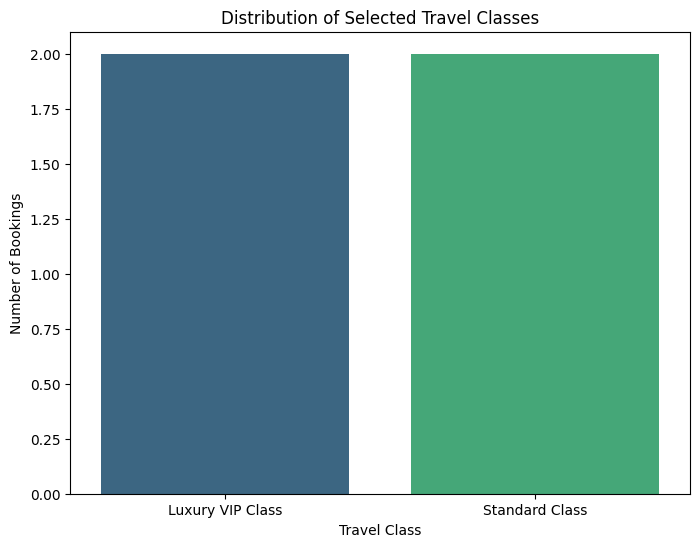

In [20]:
if not all_bookings_df.empty:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Selected_Class', data=all_bookings_df, palette='viridis')
    plt.title('Distribution of Selected Travel Classes')
    plt.xlabel('Travel Class')
    plt.ylabel('Number of Bookings')
    plt.show()
else:
    print("No data to plot.")

#### Most Popular Origin and Destination Cities

/tmp/ipykernel_1693/3874892454.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Route_Origin', data=all_bookings_df, order=all_bookings_df['Route_Origin'].value_counts().index, palette='plasma')
/tmp/ipykernel_1693/3874892454.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Route_Destination', data=all_bookings_df, order=all_bookings_df['Route_Destination'].value_counts().index, palette='mako')


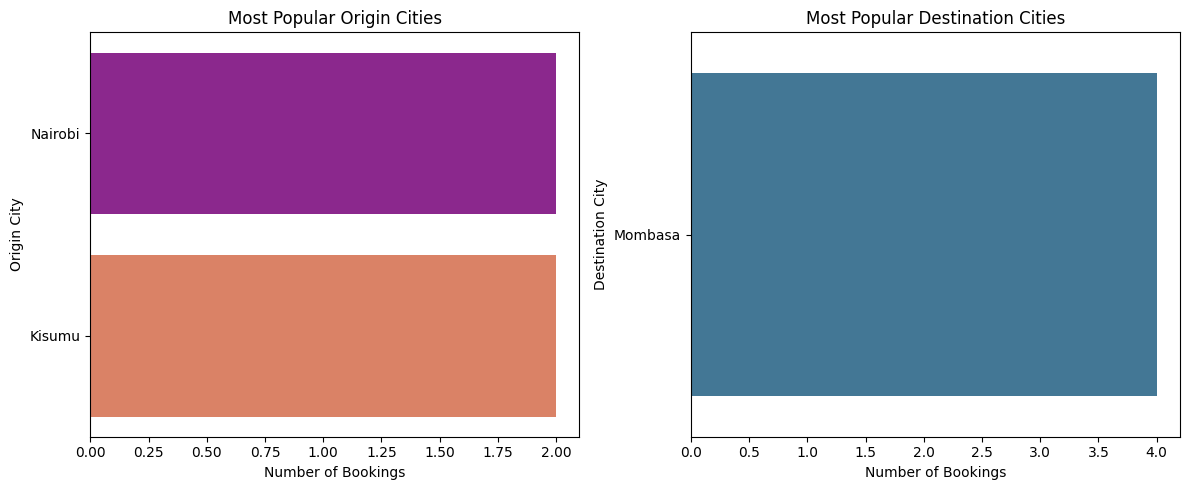

In [21]:
if not all_bookings_df.empty:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.countplot(y='Route_Origin', data=all_bookings_df, order=all_bookings_df['Route_Origin'].value_counts().index, palette='plasma')
    plt.title('Most Popular Origin Cities')
    plt.xlabel('Number of Bookings')
    plt.ylabel('Origin City')

    plt.subplot(1, 2, 2)
    sns.countplot(y='Route_Destination', data=all_bookings_df, order=all_bookings_df['Route_Destination'].value_counts().index, palette='mako')
    plt.title('Most Popular Destination Cities')
    plt.xlabel('Number of Bookings')
    plt.ylabel('Destination City')

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

## Creating a User Interface with Streamlit

To create a user interface, we'll use Streamlit. First, let's install it.

In [22]:
!pip install streamlit -q

In [23]:
%%writefile chatbot_logic.py
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.classify import NaiveBayesClassifier
import pandas as pd
from datetime import datetime

# Download necessary text parsing resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# 1. Official Agape Enterprise Core Operational Data - Updated to support routes
AGAPE_DATABASE = {
    "nairobi": {
        "mombasa": {"standard": 1500, "vip": 3000, "times": ["08:00 AM", "10:00 PM"]},
        "kisumu":  {"standard": 1200, "vip": 2500, "times": ["07:00 AM", "09:00 PM"]},
        "nakuru":  {"standard": 600,   "vip": 1200, "times": ["06:00 AM", "02:00 PM"]}
    },
    "mombasa": {
        "nairobi": {"standard": 1500, "vip": 3000, "times": ["09:00 AM", "11:00 PM"]},
        "kisumu":  {"standard": 2000, "vip": 4000, "times": ["07:00 AM", "01:00 PM"]}
    },
    "kisumu": {
        "nairobi": {"standard": 1200, "vip": 2500, "times": ["08:00 AM", "10:00 PM"]},
        "mombasa": {"standard": 2000, "vip": 4000, "times": ["07:00 AM", "01:00 PM"]}
    },
    "nakuru": {
        "nairobi": {"standard": 600,   "vip": 1200, "times": ["06:00 AM", "02:00 PM"]}
    }
}

# Dynamically extract all unique cities involved in the routes
ALL_CITIES = sorted(list(set(AGAPE_DATABASE.keys()).union(*[AGAPE_DATABASE[origin].keys() for origin in AGAPE_DATABASE])))

# 2. Train an NLTK Classifier to identify "pricing_inquiry" intents
training_corpus = [
    ("how much is a ticket to mombasa", "pricing_inquiry"),
    ("what are the bus prices for nakuru", "pricing_inquiry"),
    ("i want to check ticket rates to kisumu", "pricing_inquiry"),
    ("fare breakdown for luxury vip class", "pricing_inquiry"),
    ("how much will it cost for 3 passengers", "pricing_inquiry"),
    ("hello, good morning", "greeting"),
    ("hi there, anyone available?", "greeting"),
    ("from mombasa to kisumu price", "pricing_inquiry"),
    ("kisumu to nairobi tickets", "pricing_inquiry"),
    ("price", "pricing_inquiry"),
    ("fare", "pricing_inquiry"),
    ("cost", "pricing_inquiry"),
    ("how much", "pricing_inquiry"),
    ("no", "end_conversation"),
    ("nothing else", "end_conversation"),
    ("that's all", "end_conversation"),
    ("thank you", "end_conversation"),
    ("bye", "end_conversation"),
    ("goodbye", "end_conversation")
]

STOP_WORDS = set(stopwords.words('english'))

def extract_features(text):
    tokens = word_tokenize(text.lower())
    cleaned = [w for w in tokens if w.isalnum() and w not in STOP_WORDS]
    return {word: True for word in cleaned}

# Vectorize data and train the classifier engine
vectorized_corpus = [(extract_features(text), intent) for text, intent in training_corpus]
intent_classifier = NaiveBayesClassifier.train(vectorized_corpus)

# 3. Dynamic Extraction and Pricing Math Logic - MODIFIED for multi-turn interaction

def parse_passenger_count(text):
    clean_text = text.lower()
    number_words = {
        "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
        "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
    }
    numbers = re.findall(r'\b\d+\b', clean_text)
    if numbers:
        count = int(numbers[0])
        if count > 0:
            return count
        else:
            return 0
    for word, value in number_words.items():
        if word in clean_text:
            if re.search(r'\b' + re.escape(word) + r'\b', clean_text):
                return value
    return 0

# Define conversation states
STATE_WAITING_FOR_ROUTE = "waiting_for_route"
STATE_WAITING_FOR_PASSENGERS = "waiting_for_passengers"
STATE_WAITING_FOR_CLASS = "waiting_for_class"
STATE_COLLECTING_PASSENGER_NAME = "collecting_passenger_name"
STATE_COLLECTING_PASSENGER_PHONE = "collecting_passenger_phone"
STATE_WAITING_FOR_TRAVEL_TIME = "waiting_for_travel_time"

# Global or persistent context for the conversation
conversation_context = {
    "state": STATE_WAITING_FOR_ROUTE,
    "origin": None,
    "destination": None,
    "passenger_count": None,
    "travel_class": None,
    "full_names": [],
    "phone_numbers": [],
    "travel_time": None,
    "total_fare": None,
    "schedules": None,
    "pricing_inquiry_active": False,
    "current_passenger_index": 0
}

def reset_conversation_context():
    global conversation_context
    conversation_context = {
        "state": STATE_WAITING_FOR_ROUTE,
        "origin": None,
        "destination": None,
        "passenger_count": None,
        "travel_class": None,
        "full_names": [],
        "phone_numbers": [],
        "travel_time": None,
        "total_fare": None,
        "schedules": None,
        "pricing_inquiry_active": False,
        "current_passenger_index": 0,
    }

def process_pricing_inquiry_turn(user_input):
    global conversation_context
    clean_input = user_input.lower()
    bot_response = ""
    inquiry_completed_flag = False

    current_state = conversation_context["state"]
    passenger_count = conversation_context["passenger_count"]
    current_passenger_index = conversation_context["current_passenger_index"]

    if current_state == STATE_WAITING_FOR_ROUTE:
        origin_city = None
        destination_city = None

        city_pattern = r'\b(' + '|'.join(re.escape(city) for city in ALL_CITIES) + r')\b'
        found_cities_in_order = []
        for match in re.finditer(city_pattern, clean_input):
            found_cities_in_order.append(match.group(1))

        seen = set()
        unique_found_cities_in_order = []
        for city in found_cities_in_order:
            if city not in seen:
                unique_found_cities_in_order.append(city)
                seen.add(city)

        from_to_match = re.search(r"from\s+" + city_pattern + r"\s+to\s+" + city_pattern, clean_input)
        to_from_match = re.search(r"to\s+" + city_pattern + r"\s+from\s+" + city_pattern, clean_input)

        if from_to_match:
            origin_city = from_to_match.group(1)
            destination_city = from_to_match.group(2)
        elif to_from_match:
            destination_city = to_from_match.group(1)
            origin_city = to_from_match.group(2)
        elif len(unique_found_cities_in_order) >= 2:
            origin_city = unique_found_cities_in_order[0]
            destination_city = unique_found_cities_in_order[1]
        elif len(unique_found_cities_in_order) == 1:
            origin_city = "nairobi"
            destination_city = unique_found_cities_in_order[0]

        if not origin_city or not destination_city:
            bot_response = ("I am sorry, I couldn't identify the origin and destination cities. "
                            f"Our active routes are between {', '.join([c.title() for c in ALL_CITIES])}. Please specify your route clearly.")
            conversation_context["pricing_inquiry_active"] = False
        elif origin_city not in AGAPE_DATABASE or destination_city not in AGAPE_DATABASE[origin_city]:
            bot_response = (f"I am sorry, the route from {origin_city.title()} to {destination_city.title()} does not exist in our system at the moment. "
                            f"Our active routes are between {', '.join([c.title() for c in ALL_CITIES])}.")
            conversation_context["pricing_inquiry_active"] = False
        else:
            conversation_context["origin"] = origin_city
            conversation_context["destination"] = destination_city
            conversation_context["state"] = STATE_WAITING_FOR_PASSENGERS
            conversation_context["pricing_inquiry_active"] = True
            bot_response = "Great! How many passengers are traveling?"

    elif current_state == STATE_WAITING_FOR_PASSENGERS:
        passenger_count_input = parse_passenger_count(clean_input)
        if passenger_count_input > 0:
            conversation_context["passenger_count"] = passenger_count_input
            conversation_context["state"] = STATE_WAITING_FOR_CLASS
            bot_response = "And what class would you prefer? Please respond with 'Standard' or 'VIP'."
        else:
            bot_response = "Please enter a valid number of passengers (e.g., '2 passengers' or 'two passengers')."
            conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_WAITING_FOR_CLASS:
        travel_class = "standard"
        if "vip" in clean_input or "luxury" in clean_input:
            travel_class = "vip"
        conversation_context["travel_class"] = travel_class

        origin_city = conversation_context["origin"]
        destination_city = conversation_context["destination"]
        passenger_count = conversation_context["passenger_count"]

        route_info = AGAPE_DATABASE[origin_city][destination_city]
        base_fare = route_info[travel_class]
        total_fare = base_fare * passenger_count
        schedules = route_info["times"]

        class_label = "Luxury VIP Class" if travel_class == "vip" else "Standard Class"
        conversation_context["total_fare"] = total_fare
        conversation_context["schedules"] = schedules

        bot_response = (
            f"Hello! Welcome to Agape Enterprise. Here is your requested fare breakdown:\n\n"
            f" * Route: {origin_city.title()} to {destination_city.title()}\n"
            f" * Selected Class: {class_label}\n"
            f" * Price per Passenger: KES {base_fare:,}\n"
            f" * Number of Passengers: {passenger_count}\n"
            f" -----------------------------------------------\n"
            f" **TOTAL AMOUNT PAYABLE: KES {total_fare:,}**\n\n"
            f"Our available daily departure times for this route are: {', '.join(schedules)}.\n\n"
        )

        conversation_context["state"] = STATE_COLLECTING_PASSENGER_NAME
        conversation_context["current_passenger_index"] = 0
        bot_response += f"To proceed with booking, please provide the full name for Passenger 1."
        conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_COLLECTING_PASSENGER_NAME:
        conversation_context["full_names"].append(user_input.strip().title())
        conversation_context["state"] = STATE_COLLECTING_PASSENGER_PHONE
        bot_response = f"Thank you, {conversation_context['full_names'][current_passenger_index]}. Please provide the phone number for Passenger {current_passenger_index + 1}."
        conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_COLLECTING_PASSENGER_PHONE:
        phone_number = re.sub(r'[^0-9]', '', user_input)
        if len(phone_number) >= 8:
            conversation_context["phone_numbers"].append(phone_number)
            conversation_context["current_passenger_index"] += 1

            if conversation_context["current_passenger_index"] < passenger_count:
                conversation_context["state"] = STATE_COLLECTING_PASSENGER_NAME
                bot_response = f"Got it. Now, please provide the full name for Passenger {conversation_context['current_passenger_index'] + 1}."
            else:
                conversation_context["state"] = STATE_WAITING_FOR_TRAVEL_TIME
                available_times = conversation_context["schedules"]
                bot_response = (f"Thank you for providing all passenger details. Finally, please specify your preferred travel time for the booking "
                                f"from the available times: {', '.join(available_times)}.")
            conversation_context["pricing_inquiry_active"] = True
        else:
            bot_response = "Please enter a valid phone number with at least 8 digits."
            conversation_context["pricing_inquiry_active"] = True

    elif current_state == STATE_WAITING_FOR_TRAVEL_TIME:
        preferred_time = user_input.strip().upper()
        available_times = conversation_context["schedules"]

        if preferred_time in [t.upper() for t in available_times]:
            conversation_context["travel_time"] = preferred_time

            origin_city = conversation_context["origin"]
            destination_city = conversation_context["destination"]
            passenger_count = conversation_context["passenger_count"]
            travel_class = conversation_context["travel_class"]
            full_names = conversation_context["full_names"]
            phone_numbers = conversation_context["phone_numbers"]
            total_fare = conversation_context["total_fare"]

            class_label = "Luxury VIP Class" if travel_class == "vip" else "Standard Class"

            summary_text = f"Thank you for providing all the details!\n\nHere is a summary of your booking for the route from {origin_city.title()} to {destination_city.title()}:\n\n"
            for i in range(passenger_count):
                summary_text += f" * Passenger {i+1} Name: {full_names[i]}\n"
                summary_text += f" * Passenger {i+1} Phone: {phone_numbers[i]}\n"

            summary_text += f" * Selected Class: {class_label}\n"
            summary_text += f" * Number of Passengers: {passenger_count}\n"
            summary_text += f" * Preferred Travel Time: {preferred_time}\n"
            summary_text += f" * Total Amount Payable: KES {total_fare:,}\n\n"

            bot_response = summary_text

            booking_records = []
            for i in range(passenger_count):
                record = {
                    "Route_Origin": origin_city.title(),
                    "Route_Destination": destination_city.title(),
                    "Selected_Class": class_label,
                    "Total_Passengers_in_Booking": passenger_count,
                    "Passenger_Index": i + 1,
                    "Passenger_Name": full_names[i],
                    "Passenger_Phone": phone_numbers[i],
                    "Preferred_Travel_Time": preferred_time,
                    "Total_Amount_Payable_for_Booking": total_fare,
                }
                booking_records.append(record)

            booking_df = pd.DataFrame(booking_records)
            csv_filename = "agape_booking_" + datetime.now().strftime("%Y%m%d_%H%M%S") + ".csv"
            booking_df.to_csv(csv_filename, index=False)
            bot_response += f"Your booking details have been saved to {csv_filename}.\n\n"
            bot_response += f"A Agape Enterprise agent will contact you shortly to confirm your booking. We appreciate your trust in Agape Enterprise and look forward to serving you.\n\nHave a safe and pleasant journey!"

            reset_conversation_context()
            inquiry_completed_flag = True
        else:
            available_times_str = ', '.join(available_times)
            bot_response = (f"I'm sorry, '{user_input}' is not a valid or available time for this route. "
                            f"Please choose from: {available_times_str}.")
            conversation_context["pricing_inquiry_active"] = True
    else:
        bot_response = "An unexpected error occurred. Let's start over. Please tell me your route."
        reset_conversation_context()

    return bot_response, inquiry_completed_flag

def get_initial_greeting():
    return (f"Hello! Ask me about bus ticket prices between any of these cities: {', '.join([c.title() for c in ALL_CITIES])}. "
            "To get started, please tell me your desired route (e.g., 'Nairobi to Mombasa').")

def classify_intent(user_input):
    features = extract_features(user_input)
    return intent_classifier.classify(features)

def get_conversation_context():
    return conversation_context

def set_conversation_context(context):
    global conversation_context
    conversation_context = context

Overwriting chatbot_logic.py


Now, let's create the Streamlit application file (`streamlit_app.py`).

In [24]:
%%writefile streamlit_app.py
import streamlit as st
from chatbot_logic import (
    get_initial_greeting,
    classify_intent,
    process_pricing_inquiry_turn,
    reset_conversation_context,
    get_conversation_context,
    set_conversation_context
)

st.set_page_config(page_title="Agape Enterprise Chatbot")
st.title("🚌 Agape Enterprise Bus Booking Chatbot")

# Initialize chat history and context in session state
if "messages" not in st.session_state:
    st.session_state["messages"] = []
if "conversation_context" not in st.session_state:
    st.session_state["conversation_context"] = get_conversation_context() # Get initial context
    st.session_state["messages"].append({"role": "bot", "content": get_initial_greeting()})

# Display chat messages from history on app rerun
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

# React to user input
if prompt := st.chat_input("Ask me about bus tickets..."):
    # Display user message in chat message container
    st.chat_message("user").markdown(prompt)
    # Add user message to chat history
    st.session_state.messages.append({"role": "user", "content": prompt})

    # Restore conversation context before processing
    set_conversation_context(st.session_state["conversation_context"])

    bot_response = ""
    inquiry_completed = False

    if not st.session_state.conversation_context["pricing_inquiry_active"]:
        predicted_intent = classify_intent(prompt)

        if predicted_intent == "greeting":
            bot_response = "Hello! Welcome to Agape Enterprise. Which route's pricing or schedule can I assist you with today?"
        elif predicted_intent == "pricing_inquiry":
            st.session_state.conversation_context["pricing_inquiry_active"] = True
            bot_response, inquiry_completed = process_pricing_inquiry_turn(prompt)
        elif predicted_intent == "end_conversation":
            bot_response = "We appreciate your trust in Agape Enterprise and look forward to serving you.\n\nHave a safe and pleasant journey!"
            reset_conversation_context()
            inquiry_completed = True # Ensure context resets
        else:
            bot_response = "I'm not sure how to help with that. Please ask about bus ticket prices or say 'hello'."
    else:
        bot_response, inquiry_completed = process_pricing_inquiry_turn(prompt)

    # Save conversation context after processing
    st.session_state["conversation_context"] = get_conversation_context()

    # Display bot response
    with st.chat_message("bot"):
        st.markdown(bot_response)
    st.session_state.messages.append({"role": "bot", "content": bot_response})

    if inquiry_completed and st.session_state.conversation_context['state'] == "waiting_for_route":
        st.session_state.messages.append({"role": "bot", "content": "Is there anything else I can help you with today?"})
        st.session_state.conversation_context = get_conversation_context() # Reset to initial state for new inquiry

Overwriting streamlit_app.py


# Agape Enterprise Chatbot

This project implements a multi-turn conversational chatbot for Agape Enterprise, designed to assist users with bus ticket pricing inquiries and booking. The chatbot provides real-time fare breakdowns, collects passenger information, and saves booking details to a CSV file.

## Features

*   **Multi-Turn Conversations:** Engages users in a guided conversation to collect all necessary booking information.
*   **Route and Pricing Information:** Provides standard and VIP class pricing for various bus routes.
*   **Dynamic City Recognition:** Identifies origin and destination cities from user input.
*   **Multi-Passenger Booking:** Collects full name and phone number for each passenger in a booking.
*   **Booking Summary:** Presents a detailed summary of the booking, including route, class, passengers, and total fare.
*   **CSV Export:** Automatically saves all booking details to a CSV file for record-keeping and further processing.
*   **NLTK-powered Intent Recognition:** Uses a Naive Bayes Classifier from NLTK to understand user intent (e.g., greeting, pricing inquiry, ending conversation).


## Dependencies

*   `nltk`
*   `pandas`
*   `re`
*   `datetime`

Install using pip:

```bash
pip install nltk pandas
```

And download NLTK data:

```python
nltk.download('punkt')
nltk.download('stopwords')
```